### Import Libraries and API Functions

This cell imports necessary libraries, suppresses warnings for cleaner output, and loads the key classes and functions from the `bitcoin_utils` module.


In [3]:
%matplotlib inline


In [4]:
import warnings
warnings.filterwarnings("ignore")

!pip install --quiet --root-user-action=ignore neuralprophet

import matplotlib.pyplot as plt


### Import Forecasting and Streaming Utilities from `bitcoin_utils.py`


In [5]:
from bitcoin_utils import (
    BitcoinPriceSource,
    fetch_historical_data,
    train_neural_prophet_model,
    make_forecast,
    plot_forecast,
    plot_components
)


## Real-Time Bitcoin Price Streaming with PyFlink

This section defines and runs a streaming job that fetches live Bitcoin prices every 30 seconds and prints timestamped price updates in real-time using Apache Flink’s Python API (`pyflink`).


In [ ]:


from bitcoin_utils import BitcoinPriceSource
from pyflink.datastream import StreamExecutionEnvironment
from pyflink.common.typeinfo import Types

def main():
    env = StreamExecutionEnvironment.get_execution_environment()
    env.set_parallelism(1)

    source = BitcoinPriceSource(interval_sec=30, window_size=10)

    ds = env.from_collection(
        collection=source,
        type_info=Types.TUPLE([Types.LONG(), Types.FLOAT()])
    )

    ds.print()
    env.execute("Bitcoin Stats Streaming Job")

main()


[2025-05-18 01:18:44.224023] Price: $103315.00
[2025-05-18 01:19:14.355741] Price: $103315.00
[2025-05-18 01:19:44.437101] Price: $103315.00
[2025-05-18 01:20:14.528791] Price: $103315.00
[2025-05-18 01:20:44.671413] Price: $103314.00
[2025-05-18 01:21:14.809197] Price: $103314.00
[2025-05-18 01:21:44.909195] Price: $103314.00
[2025-05-18 01:22:14.986067] Price: $103314.00
[2025-05-18 01:22:45.051645] Price: $103314.00
[2025-05-18 01:23:15.205554] Price: $103317.00
-----> MA: $103314.70, StdDev: 0.90, EMA: $103317.00, Max: $103317.00, Min: $103314.00
        Trend: 1, Cumulative Return: 0.00%, 24h Change: 0.29%

[2025-05-18 01:23:45.330494] Price: $103317.00
-----> MA: $103314.90, StdDev: 1.14, EMA: $103317.00, Max: $103317.00, Min: $103314.00
        Trend: 1, Cumulative Return: 0.00%, 24h Change: 0.29%

[2025-05-18 01:24:15.458510] Price: $103317.00
-----> MA: $103315.10, StdDev: 1.30, EMA: $103317.00, Max: $103317.00, Min: $103314.00
        Trend: 1, Cumulative Return: 0.00%, 24h C

[2025-05-18 01:43:20.974792] Price: $103283.00
-----> MA: $103284.30, StdDev: 1.42, EMA: $103284.47, Max: $103287.00, Min: $103283.00
        Trend: -1, Cumulative Return: 0.00%, 24h Change: 0.37%

[2025-05-18 01:43:51.136380] Price: $103279.00
-----> MA: $103283.90, StdDev: 2.12, EMA: $103283.37, Max: $103287.00, Min: $103279.00
        Trend: -1, Cumulative Return: -0.00%, 24h Change: 0.36%

[2025-05-18 01:44:21.286792] Price: $103279.00
-----> MA: $103283.40, StdDev: 2.58, EMA: $103282.50, Max: $103287.00, Min: $103279.00
        Trend: -1, Cumulative Return: -0.00%, 24h Change: 0.36%

[2025-05-18 01:44:51.635388] Price: $103279.00
-----> MA: $103282.90, StdDev: 2.88, EMA: $103281.80, Max: $103287.00, Min: $103279.00
        Trend: -1, Cumulative Return: -0.00%, 24h Change: 0.36%

[2025-05-18 01:45:21.814200] Price: $103277.00
-----> MA: $103282.20, StdDev: 3.34, EMA: $103280.84, Max: $103287.00, Min: $103277.00
        Trend: -1, Cumulative Return: -0.01%, 24h Change: 0.36%

[2025-

[2025-05-18 02:04:27.200623] Price: $103289.00
-----> MA: $103267.10, StdDev: 8.01, EMA: $103270.01, Max: $103289.00, Min: $103261.00
        Trend: 1, Cumulative Return: 0.02%, 24h Change: 0.36%

[2025-05-18 02:04:57.314459] Price: $103289.00
-----> MA: $103269.10, StdDev: 10.38, EMA: $103273.81, Max: $103289.00, Min: $103261.00
        Trend: 1, Cumulative Return: 0.02%, 24h Change: 0.36%

[2025-05-18 02:05:27.450960] Price: $103290.00
-----> MA: $103271.20, StdDev: 12.12, EMA: $103277.05, Max: $103290.00, Min: $103261.00
        Trend: 1, Cumulative Return: 0.03%, 24h Change: 0.36%

[2025-05-18 02:05:57.558957] Price: $103290.00
-----> MA: $103274.10, StdDev: 12.79, EMA: $103279.64, Max: $103290.00, Min: $103261.00
        Trend: 1, Cumulative Return: 0.03%, 24h Change: 0.36%

[2025-05-18 02:06:27.657295] Price: $103290.00
-----> MA: $103277.00, StdDev: 12.77, EMA: $103281.71, Max: $103290.00, Min: $103262.00
        Trend: 1, Cumulative Return: 0.03%, 24h Change: 0.36%

[2025-05-18

[2025-05-18 02:25:33.641155] Price: $103319.00
-----> MA: $103319.00, StdDev: 2.76, EMA: $103318.54, Max: $103322.00, Min: $103315.00
        Trend: 1, Cumulative Return: 0.00%, 24h Change: 0.30%

[2025-05-18 02:26:03.766564] Price: $103319.00
-----> MA: $103319.40, StdDev: 2.42, EMA: $103318.64, Max: $103322.00, Min: $103315.00
        Trend: 1, Cumulative Return: 0.00%, 24h Change: 0.30%

[2025-05-18 02:26:33.867138] Price: $103319.00
-----> MA: $103319.80, StdDev: 1.94, EMA: $103318.71, Max: $103322.00, Min: $103315.00
        Trend: 1, Cumulative Return: 0.00%, 24h Change: 0.30%

[2025-05-18 02:27:03.935233] Price: $103317.00
-----> MA: $103320.00, StdDev: 1.48, EMA: $103318.37, Max: $103322.00, Min: $103317.00
        Trend: -1, Cumulative Return: -0.00%, 24h Change: 0.22%

[2025-05-18 02:27:34.258467] Price: $103317.00
-----> MA: $103319.70, StdDev: 1.73, EMA: $103318.09, Max: $103322.00, Min: $103317.00
        Trend: -1, Cumulative Return: -0.00%, 24h Change: 0.22%

[2025-05-18

# Fetch and Preview Historical Bitcoin Price Data

This section downloads historical Bitcoin price data from Yahoo Finance and displays the first few records for verification.


In [7]:
btc_data = fetch_historical_data()
btc_data.head()  # Display first few rows to confirm


YF.download() has changed argument auto_adjust default to True


,ds,y
0,2014-09-17,457.334015
1,2014-09-18,424.440002
2,2014-09-19,394.795990
3,2014-09-20,408.903992
4,2014-09-21,398.821014


# Train Prophet Forecasting Model

This section trains a Prophet time series forecasting model using the historical Bitcoin price data.


In [8]:
model = train_neural_prophet_model(btc_data)

print("Model training complete.")


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.949% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 70
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (61) is too small than the required number                     for the learning rate finder (240). The results might not be optimal.
Finding best initial lr: 100%|██████████| 240/240 [00:00<00:00, 771.99it/s]


Epoch 70: 100%|██████████| 70/70 [00:00<00:00, 947.56it/s, loss=0.0146, v_num=3, MAE=5.64e+3, RMSE=7.2e+3, Loss=0.0148, RegLoss=0.000]    
Model training complete.


# Generate Forecast with Prophet Model

This section generates future Bitcoin price predictions using the trained Prophet model and displays the last 10 forecasted values including confidence intervals.


In [9]:
forecast = make_forecast(model, btc_data)
forecast[['ds', 'yhat1']].tail(10)



INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.949% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 734.94it/s] 

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


,ds,yhat1
355,2026-05-09,115678.531250
356,2026-05-10,115493.906250
357,2026-05-11,115404.296875
358,2026-05-12,115686.335938
359,2026-05-13,115632.804688
360,2026-05-14,115389.648438
361,2026-05-15,115584.296875
362,2026-05-16,115355.468750
363,2026-05-17,115156.273438
364,2026-05-18,115327.703125


### Displaying Bitcoin Price Forecast for the Next 7 Days


In [10]:
forecast = make_forecast(model, btc_data)

last_date = btc_data['ds'].max()
future_forecast = forecast[forecast['ds'] > last_date]

print("Bitcoin price forecast for next 7 days:")
print(future_forecast[['ds', 'yhat1']].head(7))


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.949% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 624.62it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column



Bitcoin price forecast for next 7 days:
          ds         yhat1
0 2025-05-19  89362.687500
1 2025-05-20  89329.046875
2 2025-05-21  89453.546875
3 2025-05-22  89260.140625
4 2025-05-23  89231.664062
5 2025-05-24  89188.734375
6 2025-05-25  88968.937500


### Visualizing Bitcoin Price Forecast (Next 1 Year)


WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


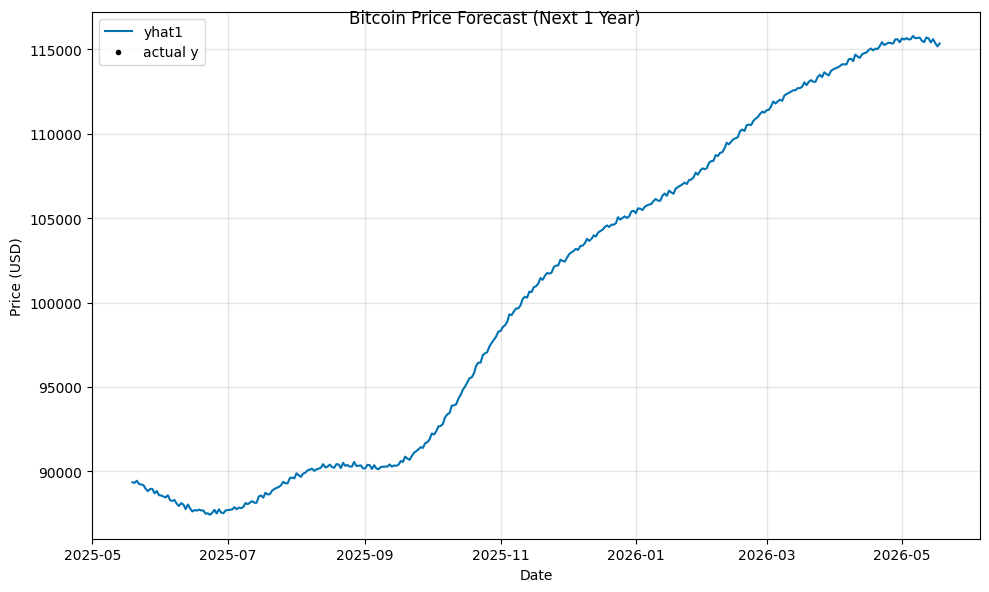

In [11]:
plot_forecast(model, forecast)



### Visualizing Forecast Components: Trend and Seasonality


WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


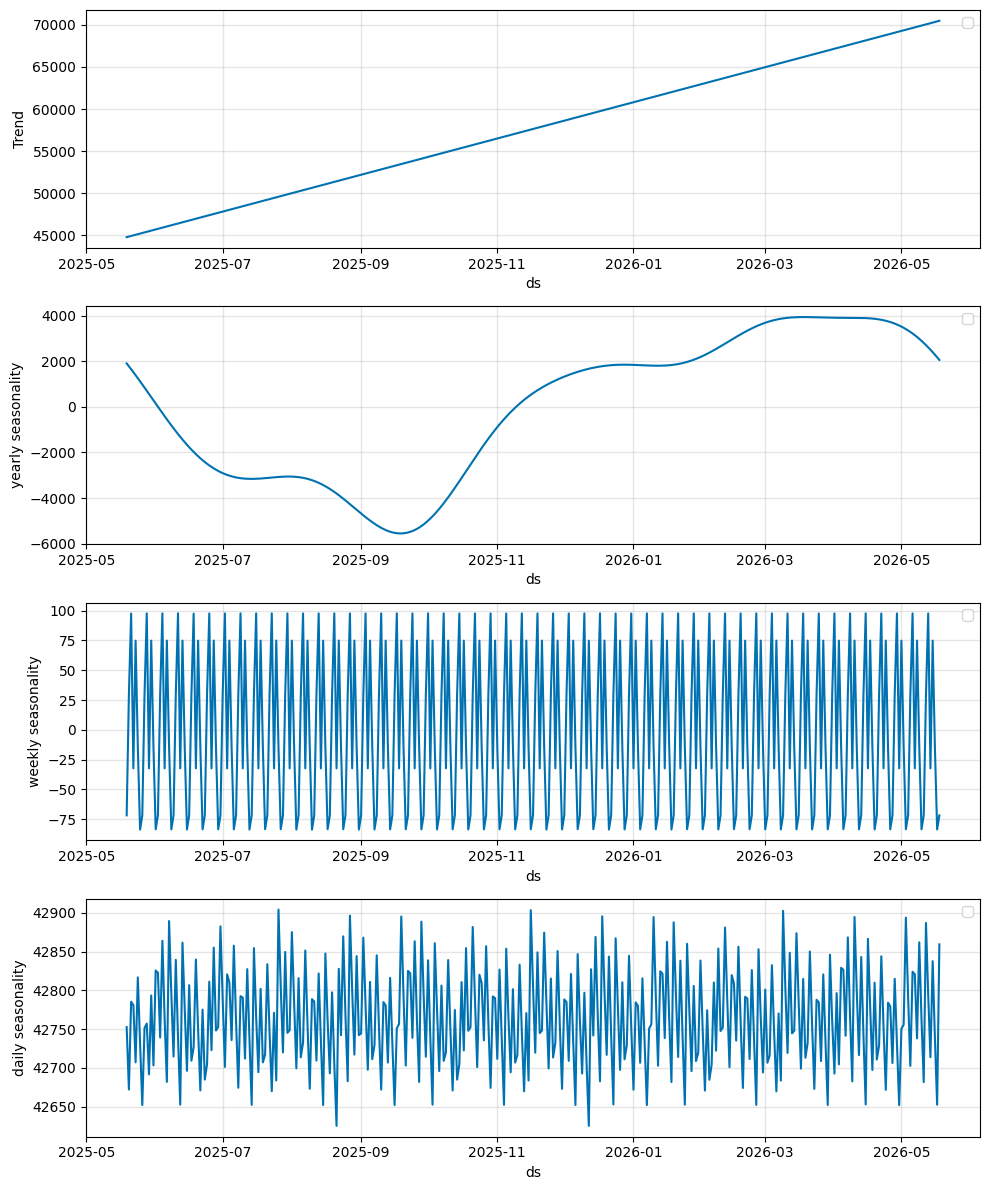

In [12]:
plot_components(model, forecast)


